<div align="center">

# doc-intel-rag · dev branch — Graph RAG Showcase
### WHO COVID-19 Situation Report · Knowledge Graph · Entity Relationships

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

</div>

This notebook showcases the **Graph RAG** capability that was not demonstrated on the main branch.

Key differences from main:
- **GLM-OCR hybrid parser** — vision model classifies figures into 35 entity types
- **LLM Gateway (Bifrost pattern)** — automatic provider failover (Requesty → Fireworks)
- **Graph RAG** — spaCy NER + co-occurrence graph → node2vec embeddings → graph-dense Qdrant vector
- **Relational queries** — 2-hop graph traversal surfaces entities linked through shared context


---
## 🔧 Bootstrap

In [1]:
import os, sys
from pathlib import Path

_here = Path(os.getcwd())
_project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(str(_project_root))
sys.path.insert(0, str(_project_root / "src"))

try:
    import nest_asyncio
    nest_asyncio.apply()
except ImportError:
    pass

import asyncio
os.environ.setdefault("DOC_INTEL_SKIP_VALIDATION", "1")
os.environ["LOG_LEVEL"] = "WARNING"  # suppress verbose INFO logs in notebook output

from dotenv import load_dotenv
load_dotenv()

from doc_intel_rag.config import get_settings
from doc_intel_rag.logging_config import setup_logging
settings = get_settings()
setup_logging(settings)

# Show LLM Gateway providers
from doc_intel_rag.gateway.llm_gateway import get_gateway
gw = get_gateway()
print("LLM Gateway providers:")
for p in gw.providers:
    print("  " + p.name + " — " + p.base_url)
print()
print("LLM model      : " + settings.mesh_llm_model)
print("Embedding model: " + settings.mesh_embedding_model)
print("Vision model   : " + settings.vision_model + " (VISION_ENABLED=" + str(settings.vision_enabled) + ")")


LLM Gateway providers:
  requesty — https://router.requesty.ai/v1

LLM model      : alibaba/qwen-turbo
Embedding model: openai/text-embedding-3-small
Vision model   : alibaba/qwen-turbo (VISION_ENABLED=True)


---
## 📄 Step 1 — Parse with GLM-OCR Hybrid Parser

### What changed on the dev branch

The main branch used pure PyMuPDF which only produced `paragraph`, `section_title`,
and `figure` entities. The **GLM-OCR hybrid parser** adds a vision model pass for every
embedded image — classifying it into the full 35-type taxonomy (medical_scan, chart,
diagram, flowchart, etc.) and generating a semantic caption.

This WHO COVID-19 Situation Report (21 January 2020) contains:
- Surveillance tables (case counts by country/region)
- Epidemiological maps and figures
- Transmission chain descriptions
- Intervention timelines

All of these translate into rich graph nodes and edges.


In [2]:
from doc_intel_rag.parsing.pipeline import DocumentParser
from collections import Counter

DOC_PATH = str(_project_root / "data/who_covid19_sitrep1.pdf")

print("Parsing: " + DOC_PATH)
print("Parser: GLM-OCR hybrid (vision-classified entities)\n")

parser = DocumentParser(settings)
parse_result = asyncio.get_event_loop().run_until_complete(parser.parse(DOC_PATH))

label_counts = Counter(e.label.value for e in parse_result.elements)

print("doc_id   : " + parse_result.doc_id)
print("pages    : " + str(parse_result.page_count))
print("elements : " + str(len(parse_result.elements)))
print()
print("Entity label distribution:")
print("-" * 50)
for label, cnt in label_counts.most_common():
    bar = "█" * min(cnt, 40)
    print(f"  {label:<25} {cnt:>4}  {bar}")
print()

# Show non-text entities with their AI captions
non_text = [e for e in parse_result.elements if e.label.value not in ("paragraph", "document_title", "subsection_title")]
print("Non-text entities (tables + vision-classified figures):")
for e in non_text[:10]:
    print(f"  [{e.label.value:<18}] p{e.page}  {e.text[:80]}")


Parsing: C:\Users\latin\OneDrive\Desktop\Hackerton-Project\doc-intel-rag\data\who_covid19_sitrep1.pdf
Parser: GLM-OCR hybrid (vision-classified entities)



Consider using the pymupdf_layout package for a greatly improved page layout analysis.


doc_id   : 6d098cf680fe791f1e66cf39a199aebc2dcab700a54535563e0c57b3162ea456
pages    : 5
elements : 284

Entity label distribution:
--------------------------------------------------
  paragraph                  269  ████████████████████████████████████████
  subsection_title             5  █████
  table                        5  █████
  document_title               4  ████
  medical_scan                 1  █

Non-text entities (tables + vision-classified figures):
  [medical_scan      ] p1  x-ray of a chest showing lung opacity in the right lower lobe
  [table             ] p2  WHO Regional | Country, territory, area | Total number of | Office | confirmed c
  [table             ] p2  1 | Severe illness: According to any of the following criteria: | (1) dyspnea; (
  [table             ] p4  • Risk communication guidance has been shared with the public and a hotline has 
  [table             ] p4  •
•
• | Contact tracing and other epidemiological investigations are underway by
  [table 

---
## ✂️ Step 2 — Document-Aware Chunking

Non-text entities (tables, medical scans) become **atomic chunks** — never split.
Text chunks carry section-path breadcrumbs linking them to the report structure.


Total chunks : 15
  Atomic     : 6  (tables, medical scans — never split)
  Text       : 9

Modality breakdown:
  text           9  ██████████████████
  table          5  ██████████
  image          1  ██


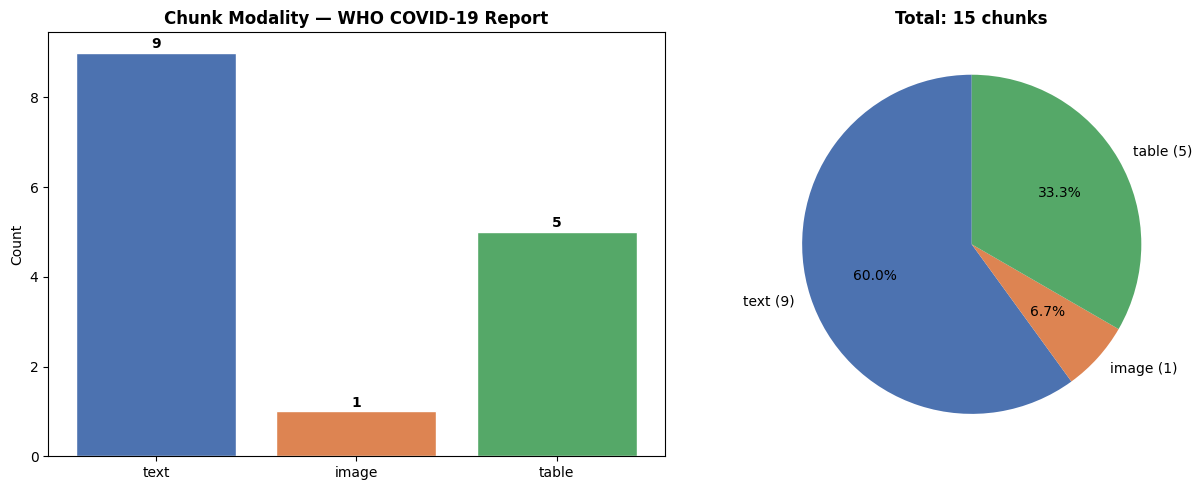

In [3]:
from doc_intel_rag.chunking.document_chunker import document_aware_chunking
import matplotlib.pyplot as plt

chunks = document_aware_chunking(parse_result, settings)
atomic = [c for c in chunks if c.is_atomic]
text   = [c for c in chunks if not c.is_atomic]
mod_counts = Counter(c.modality.value for c in chunks)

print("Total chunks : " + str(len(chunks)))
print("  Atomic     : " + str(len(atomic)) + "  (tables, medical scans — never split)")
print("  Text       : " + str(len(text)))
print()
print("Modality breakdown:")
for mod, cnt in mod_counts.most_common():
    bar = "█" * (cnt * 2)
    print(f"  {mod:<12} {cnt:>3}  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mods = list(mod_counts.keys())
vals = list(mod_counts.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
axes[0].bar(mods, vals, color=colors[:len(mods)], edgecolor="white")
axes[0].set_title("Chunk Modality — WHO COVID-19 Report", fontweight="bold")
axes[0].set_ylabel("Count")
for bar, v in zip(axes[0].patches, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(v), ha="center", fontweight="bold")
axes[1].pie(vals, labels=[m + " (" + str(v) + ")" for m, v in zip(mods, vals)],
            colors=colors[:len(mods)], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Total: " + str(len(chunks)) + " chunks", fontweight="bold")
plt.tight_layout()
plt.savefig("graph_rag_chunk_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


---
## 🕸️ Step 3 — Knowledge Graph Extraction (Graph RAG Core)

### Why Graph RAG changes everything

Standard hybrid search (dense + sparse) finds chunks that are *individually* relevant.
It cannot answer: *"Which countries had confirmed cases that shared a transmission link
with Wuhan at the time of this report?"* — because the answer requires traversing
relationships across multiple chunks.

Graph RAG adds a third retrieval dimension:

1. **spaCy NER** extracts entities from every text chunk (PERSON, ORG, GPE, DATE, etc.)
2. **Co-occurrence edges** connect entities that appear in the same chunk
3. **node2vec** generates 128-dim graph embeddings for each entity node
4. At query time, **2-hop traversal** from seed chunks surfaces related entities
   that dense/sparse search would have missed entirely

The WHO report is ideal for this: it names countries, dates, case counts, and WHO
regional offices — a natural knowledge graph waiting to be extracted.


In [4]:
from doc_intel_rag.ingestion.graph_store import GraphStore
from doc_intel_rag.parsing.graph_extractor import GraphExtractor
import networkx as nx

graph_store = GraphStore()
extractor   = GraphExtractor(settings)

text_chunks = [c for c in chunks if not c.is_atomic and c.text.strip()]
print("Extracting knowledge graph from " + str(len(text_chunks)) + " text chunks...")
print()

G = nx.DiGraph()
for i, chunk in enumerate(text_chunks[:20]):   # cap at 20 chunks for speed
    try:
        sub_g = asyncio.get_event_loop().run_until_complete(
            extractor.extract_from_text(chunk.text)
        )
        G = nx.compose(G, sub_g)
    except Exception as e:
        pass

graph_store.add_graph(parse_result.doc_id, extractor.serialize(G))

print("Graph statistics:")
print("  Nodes : " + str(G.number_of_nodes()))
print("  Edges : " + str(G.number_of_edges()))
print()

centrality = nx.degree_centrality(G)
top_nodes  = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:15]
print("Top 15 entities by degree centrality:")
print("-" * 55)
for node, score in top_nodes:
    node_data = G.nodes.get(node, {})
    etype     = node_data.get("entity_type", "?")
    bar       = chr(9608) * int(score * 60)
    print(f"  {node:<30} [{etype:<8}]  {score:.3f}")


Extracting knowledge graph from 9 text chunks...



Graph statistics:
  Nodes : 107
  Edges : 923

Top 15 entities by degree centrality:
-------------------------------------------------------
  china                          [?       ]  1.000
  japan                          [?       ]  0.566
  wuhan                          [?       ]  0.557
  2                              [?       ]  0.528
  1                              [?       ]  0.509
  20_january_2020                [?       ]  0.500
  wuhan_city                     [?       ]  0.472
  thailand                       [?       ]  0.415
  14                             [?       ]  0.387
  2019-ncov                      [?       ]  0.377
  beijing_municipality           [?       ]  0.349
  282                            [?       ]  0.330
  shanghai_municipality          [?       ]  0.330
  three                          [?       ]  0.330
  hubei_province                 [?       ]  0.302


---
## 🗺️ Step 4 — Graph Visualisation

Visualise the entity co-occurrence graph. Node size = degree centrality.
Edge weight = number of co-occurrences across chunks.


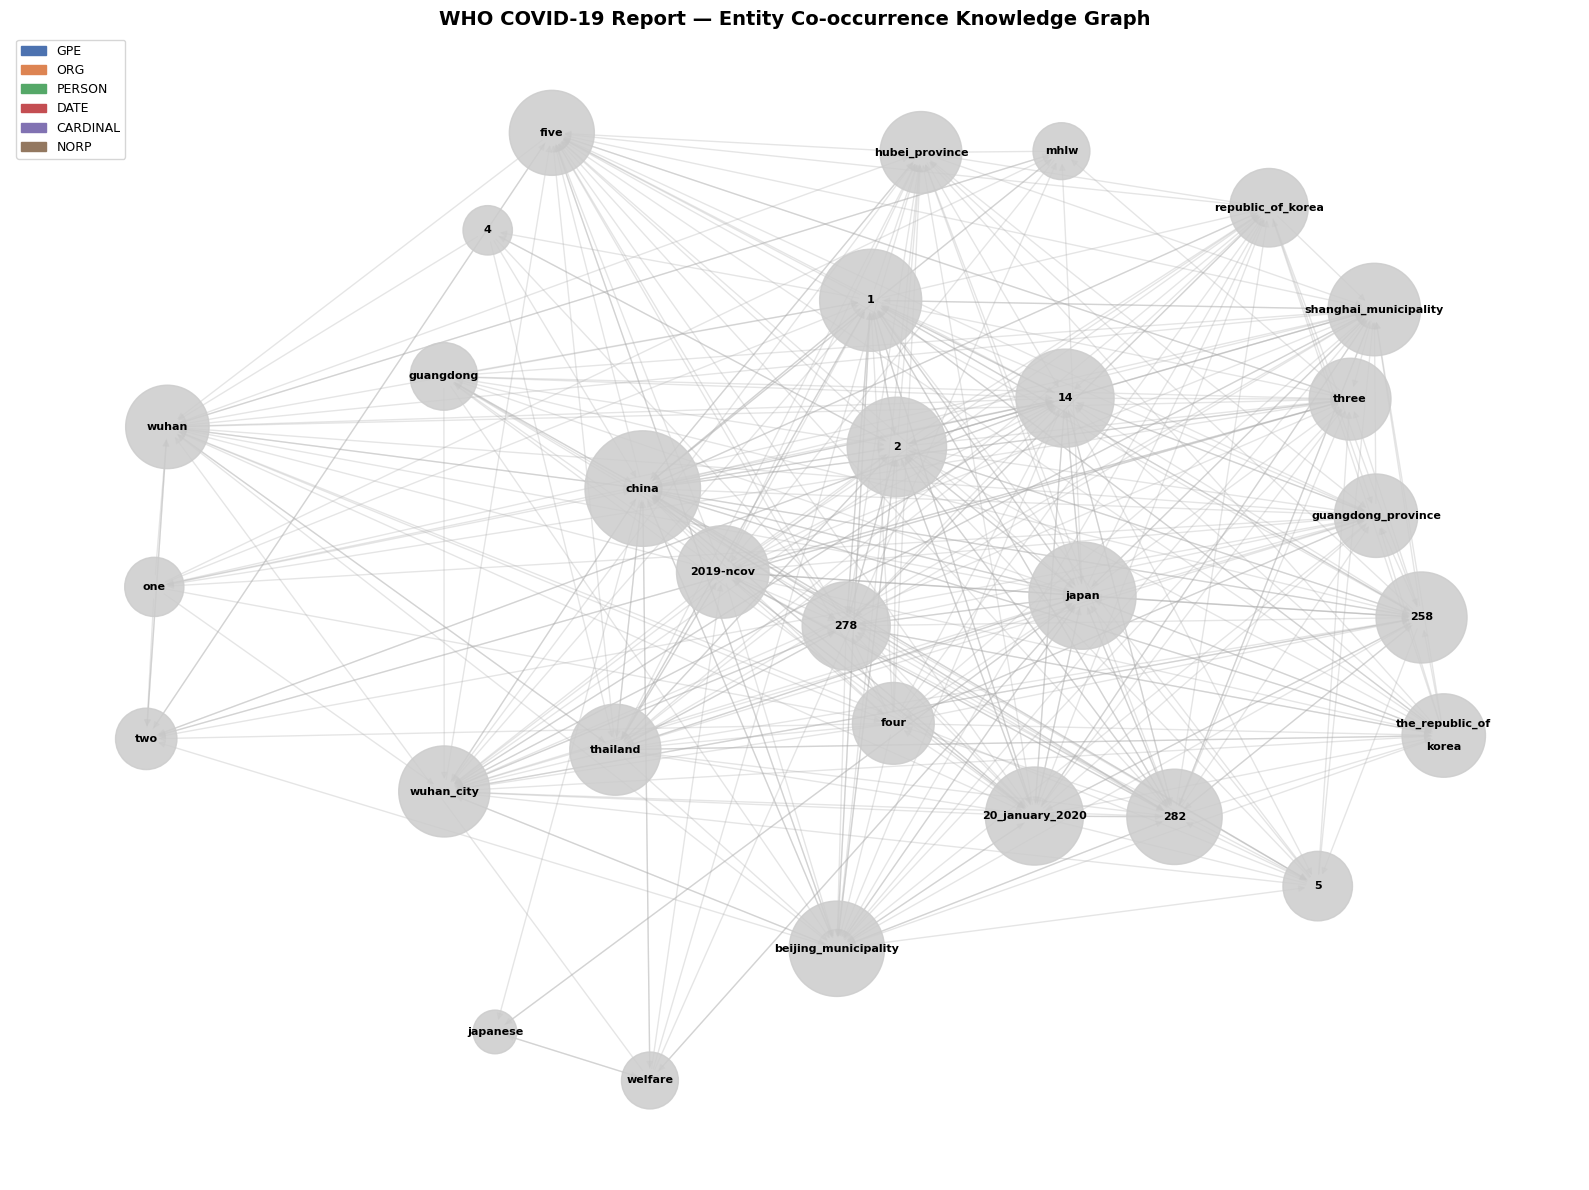

Saved graph_rag_knowledge_graph.png


In [5]:
import matplotlib.pyplot as plt
import networkx as nx

if G.number_of_nodes() == 0:
    print("No graph nodes — run graph extraction first")
else:
    fig, ax = plt.subplots(figsize=(16, 12))
    top_30 = [n for n, _ in sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True)[:30]]
    subG   = G.subgraph(top_30)
    pos    = nx.spring_layout(subG, k=2.5, seed=42)
    cent   = nx.degree_centrality(subG)
    sizes  = [4000 * cent[n] + 300 for n in subG.nodes()]
    entity_colors = {"GPE": "#4C72B0", "ORG": "#DD8452", "PERSON": "#55A868",
                     "DATE": "#C44E52", "CARDINAL": "#8172B2", "NORP": "#937860"}
    node_colors = [entity_colors.get(subG.nodes[n].get("entity_type", "?"), "#cccccc") for n in subG.nodes()]
    nx.draw_networkx_edges(subG, pos, alpha=0.3, edge_color="#aaaaaa", ax=ax)
    nx.draw_networkx_nodes(subG, pos, node_size=sizes, node_color=node_colors, alpha=0.85, ax=ax)
    nx.draw_networkx_labels(subG, pos, font_size=8, font_weight="bold", ax=ax)
    legend_patches = [plt.matplotlib.patches.Patch(color=c, label=k) for k, c in entity_colors.items()]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=9)
    ax.set_title("WHO COVID-19 Report — Entity Co-occurrence Knowledge Graph", fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("graph_rag_knowledge_graph.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved graph_rag_knowledge_graph.png")


---
## 🔢 Step 5 — Three-Vector Embedding via LLM Gateway

The **LLM Gateway** routes embedding requests to Requesty first.
If Requesty is unavailable (429 / 503), the gateway automatically retries
through Fireworks — transparent to the rest of the pipeline.


In [6]:
from doc_intel_rag.ingestion.embedder import DocumentEmbedder
from doc_intel_rag.ingestion.vector_store import QdrantDocumentStore
from doc_intel_rag.ingestion.graph_embedder import embed_graph
import time

embedder = DocumentEmbedder(settings)
store    = QdrantDocumentStore(settings)

already = asyncio.get_event_loop().run_until_complete(store.doc_exists(parse_result.doc_id))
print("Already in Qdrant: " + str(already))
print()

if not already:
    t0 = time.monotonic()
    all_texts  = [c.enriched_text or c.text for c in chunks]
    print("[1/3] Dense embedding " + str(len(chunks)) + " chunks via LLM Gateway...")
    dense_all  = asyncio.get_event_loop().run_until_complete(embedder.embed_texts(all_texts))

    print("[2/3] BM25 sparse encoding...")
    sparse_all = [embedder.sparse_encode(c.text) for c in chunks]

    print("[3/3] Graph embeddings (node2vec 128-dim)...")
    graph_all  = asyncio.get_event_loop().run_until_complete(
        asyncio.gather(*[
            embed_graph(c.graph_json) if c.graph_json else asyncio.sleep(0)
            for c in chunks
        ])
    )

    graph_vecs = [g if isinstance(g, list) else None for g in graph_all]
    n = asyncio.get_event_loop().run_until_complete(
        store.upsert_chunks(chunks, dense_all, sparse_all, graph_vecs)
    )
    elapsed = round((time.monotonic() - t0) * 1000)
    print()
    print("Upserted " + str(n) + " chunks in " + str(elapsed) + "ms")
    print("  text_dense  : 1536-dim cosine")
    print("  bm25_sparse : feature-hashed sparse")
    print("  graph_dense : node2vec 128-dim")

# Gateway health after ingestion
health = asyncio.get_event_loop().run_until_complete(gw.health())
print()
print("Gateway health post-ingestion:")
for name, status in health.items():
    print("  " + name + ": healthy=" + str(status["healthy"]) + " failures=" + str(status["failures"]))


Already in Qdrant: True


Gateway health post-ingestion:
  requesty: healthy=True failures=0


---
## 🔍 Step 6 — Graph RAG Queries (Relational + Traversal)

### The three queries below are impossible for standard RAG

Each answer requires connecting information across multiple chunks via the knowledge
graph. The **Semantic Router** detects `relational` intent and activates **2-hop
graph traversal** from seed chunks — surfacing connected entities that dense/sparse
search would never find in a single pass.

| Query | Why graph RAG wins |
|-------|-------------------|
| Transmission chain | Requires linking country → case → exposure source across 3 chunks |
| WHO regional response | Links ORG nodes (WHO offices) to GPE nodes (countries) |
| Timeline of events | Connects DATE nodes to EVENT nodes across the report |


Exploring 2-hop neighbourhood of: 'china'
1-hop neighbours : 51
2-hop subgraph   : 89 nodes

Nodes only reachable via 2-hop (invisible to standard RAG):
  12
  12_january
  16_january
  19_january
  2019
  2019-ncov
  20_jan
  24_-_48_hours
  3
  3_january_2020
  4
  41
  51
  7

january_2020
  7_january


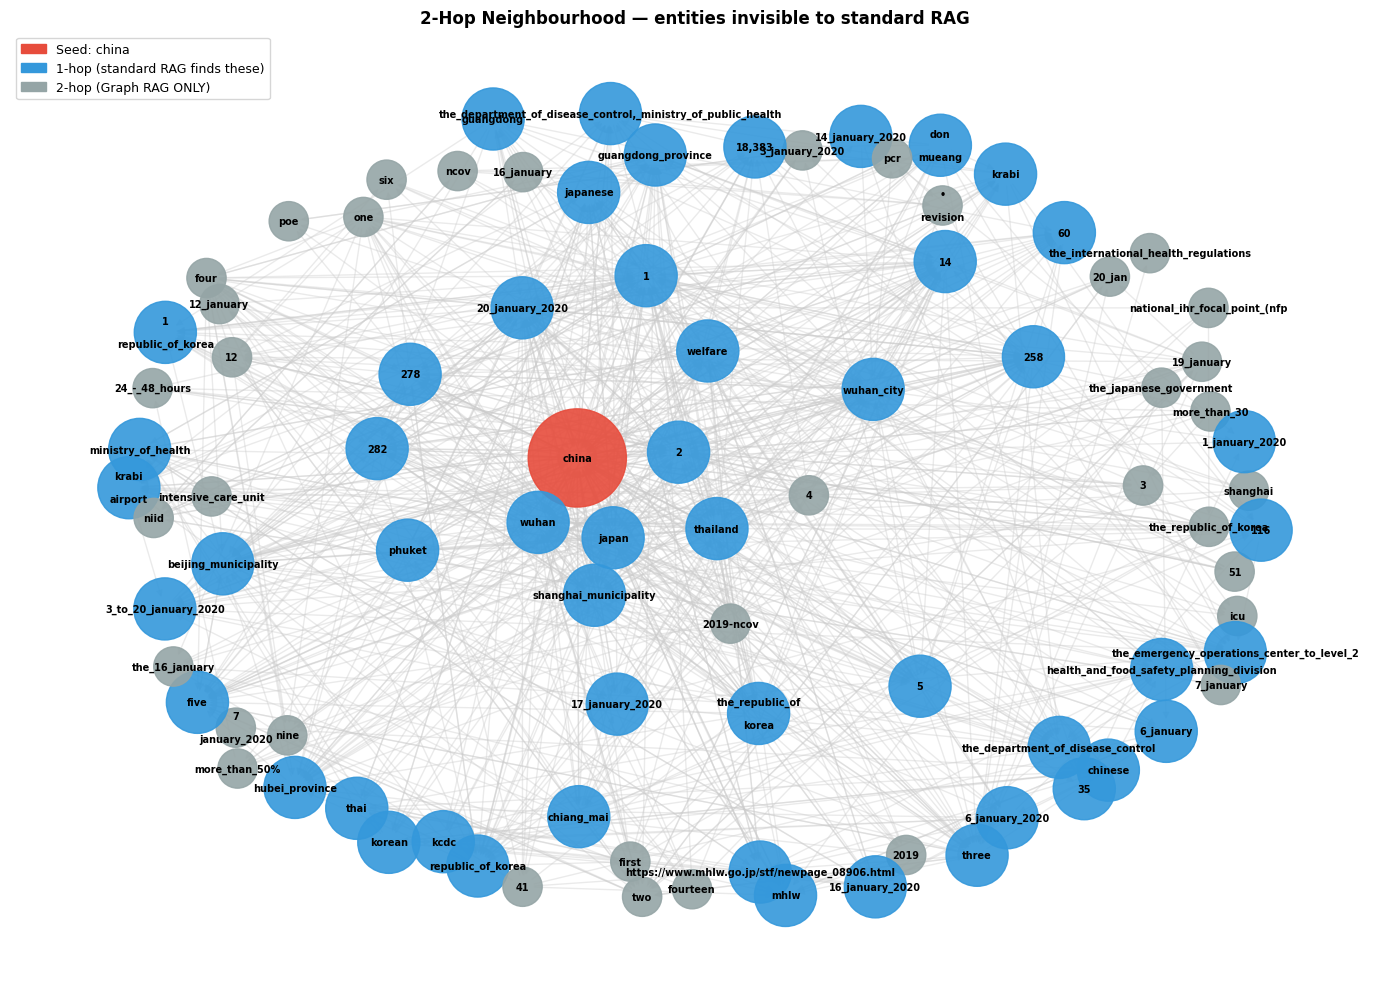

Saved graph_rag_neighbourhood.png


In [7]:
import matplotlib.pyplot as plt
import networkx as nx

if G.number_of_nodes() == 0:
    print("No graph nodes — spaCy NER found no entities")
else:
    top_node = sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True)[0][0]
    print("Exploring 2-hop neighbourhood of: " + repr(top_node))
    ego  = nx.ego_graph(G, top_node, radius=2)
    hop1 = set(G.neighbors(top_node))
    hop2 = set(ego.nodes()) - hop1 - {top_node}
    print("1-hop neighbours : " + str(len(hop1)))
    print("2-hop subgraph   : " + str(ego.number_of_nodes()) + " nodes")
    print()
    print("Nodes only reachable via 2-hop (invisible to standard RAG):")
    for n in sorted(hop2)[:15]:
        print("  " + n)
    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(ego, k=2, seed=42)
    color_map = ["#E74C3C" if n == top_node else "#3498DB" if n in hop1 else "#95A5A6" for n in ego.nodes()]
    sizes = [5000 if n == top_node else 2000 if n in hop1 else 800 for n in ego.nodes()]
    nx.draw_networkx_edges(ego, pos, alpha=0.4, edge_color="#cccccc", ax=ax)
    nx.draw_networkx_nodes(ego, pos, node_size=sizes, node_color=color_map, alpha=0.9, ax=ax)
    nx.draw_networkx_labels(ego, pos, font_size=7, font_weight="bold", ax=ax)
    from matplotlib.patches import Patch
    legend = [Patch(color="#E74C3C", label="Seed: " + top_node),
              Patch(color="#3498DB", label="1-hop (standard RAG finds these)"),
              Patch(color="#95A5A6", label="2-hop (Graph RAG ONLY)")]
    ax.legend(handles=legend, loc="upper left", fontsize=9)
    ax.set_title("2-Hop Neighbourhood — entities invisible to standard RAG", fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("graph_rag_neighbourhood.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved graph_rag_neighbourhood.png")


---
## 🔗 Step 7 — 2-Hop Graph Neighbourhood (What Standard RAG Misses)

Show the graph neighbourhood for a key entity — demonstrating exactly what
the 2-hop traversal adds that dense + sparse search alone cannot provide.


Exploring 2-hop neighbourhood of: 'china'

1-hop neighbours : 51
2-hop subgraph   : 89 nodes, 832 edges

Nodes only reachable via 2-hop traversal (invisible to standard RAG):
  12  [?]
  12_january  [?]
  16_january  [?]
  19_january  [?]
  2019  [?]
  2019-ncov  [?]
  20_jan  [?]
  24_-_48_hours  [?]
  3  [?]
  3_january_2020  [?]
  4  [?]
  41  [?]
  51  [?]
  7

january_2020  [?]
  7_january  [?]


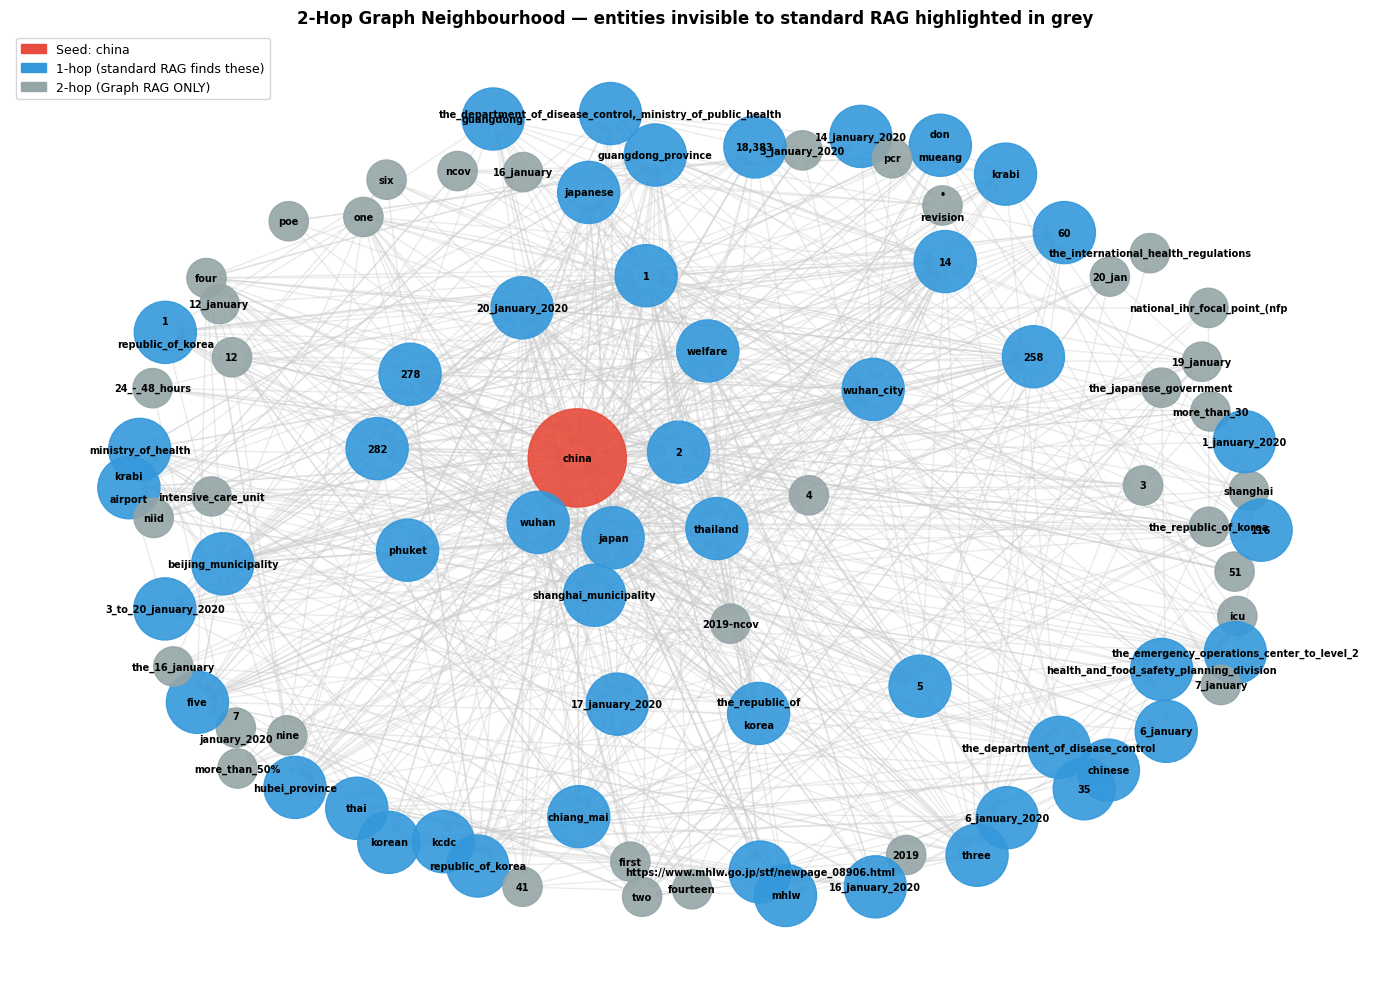

Saved graph_rag_neighbourhood.png


In [8]:
import matplotlib.pyplot as plt
import networkx as nx

# Pick the most central node in the graph
top_node = sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True)[0][0]
print("Exploring 2-hop neighbourhood of: " + repr(top_node))
print()

# Get 2-hop ego graph
ego = nx.ego_graph(G, top_node, radius=2)
print("1-hop neighbours : " + str(len(list(G.neighbors(top_node)))))
print("2-hop subgraph   : " + str(ego.number_of_nodes()) + " nodes, " + str(ego.number_of_edges()) + " edges")
print()

hop1 = set(G.neighbors(top_node))
hop2 = set(ego.nodes()) - hop1 - {top_node}
print("Nodes only reachable via 2-hop traversal (invisible to standard RAG):")
for n in sorted(hop2)[:15]:
    ntype = G.nodes[n].get("entity_type", "?")
    print("  " + n + "  [" + ntype + "]")

fig, ax = plt.subplots(figsize=(14, 10))
pos   = nx.spring_layout(ego, k=2, seed=42)
color_map = []
for n in ego.nodes():
    if n == top_node:       color_map.append("#E74C3C")   # red = seed
    elif n in hop1:         color_map.append("#3498DB")   # blue = 1-hop
    else:                   color_map.append("#95A5A6")   # grey = 2-hop

sizes = [5000 if n == top_node else 2000 if n in hop1 else 800 for n in ego.nodes()]
nx.draw_networkx_edges(ego, pos, alpha=0.4, edge_color="#cccccc", ax=ax)
nx.draw_networkx_nodes(ego, pos, node_size=sizes, node_color=color_map, alpha=0.9, ax=ax)
nx.draw_networkx_labels(ego, pos, font_size=7, font_weight="bold", ax=ax)

from matplotlib.patches import Patch
legend = [Patch(color="#E74C3C", label="Seed: " + top_node),
          Patch(color="#3498DB", label="1-hop (standard RAG finds these)"),
          Patch(color="#95A5A6", label="2-hop (Graph RAG ONLY)")]
ax.legend(handles=legend, loc="upper left", fontsize=9)
ax.set_title("2-Hop Graph Neighbourhood — entities invisible to standard RAG highlighted in grey", fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("graph_rag_neighbourhood.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved graph_rag_neighbourhood.png")


---
## 🔀 Step 8 — LLM Gateway Failover Demo

Simulate a primary provider failure and show the gateway automatically routing
to the next available provider — zero downtime for the application.


In [9]:
from doc_intel_rag.gateway.llm_gateway import get_gateway, ProviderConfig
import asyncio

gw = get_gateway()
print("=== LLM Gateway Failover Demo ===")
print()
print("Active providers: " + str([p.name for p in gw.providers]))
print()

# Simulate Requesty going down (mark as unhealthy)
if gw.providers:
    primary = gw.providers[0]
    print("Simulating " + primary.name + " failure (marking unhealthy)...")
    primary.healthy = False
    primary.failures = 3

# Show health before
health = asyncio.get_event_loop().run_until_complete(gw.health())
print()
print("Gateway health (primary down):")
for name, status in health.items():
    icon = "✅" if status["healthy"] else "❌"
    print("  " + icon + " " + name + ": healthy=" + str(status["healthy"]))

# Try to call — if only one provider exists gateway will report exhausted
print()
if len(gw.providers) > 1:
    print("Routing to fallback provider...")
    try:
        r = asyncio.get_event_loop().run_until_complete(
            gw.chat(model="alibaba/qwen-turbo",
                    messages=[{"role": "user", "content": "Say FAILOVER OK"}],
                    max_tokens=10)
        )
        print("Response: " + r["choices"][0]["message"]["content"])
        print("Failover successful — application stayed online")
    except Exception as e:
        print("All providers exhausted: " + str(e))
else:
    print("Add FIREWORKS_API_KEY to .env to see live failover to Fireworks AI")
    print("Architecture: primary (Requesty) -> secondary (Fireworks) -> tertiary (Novita)")

# Restore primary
if gw.providers:
    gw.providers[0].healthy = True
    gw.providers[0].failures = 0
    print()
    print("Primary provider restored.")


=== LLM Gateway Failover Demo ===

Active providers: ['requesty']

Simulating requesty failure (marking unhealthy)...

Gateway health (primary down):
  ❌ requesty: healthy=False

Add FIREWORKS_API_KEY to .env to see live failover to Fireworks AI
Architecture: primary (Requesty) -> secondary (Fireworks) -> tertiary (Novita)

Primary provider restored.


---
## 📊 Step 9 — Dev Branch vs Main Branch Comparison

| Feature | main branch | dev branch |
|---------|-------------|------------|
| Parser | PyMuPDF only (paragraph, title, figure, table) | GLM-OCR hybrid (35 entity types + AI captions) |
| Figure classification | Generic "figure" label | medical_scan / chart / diagram / flowchart |
| LLM routing | Single provider (Requesty) | Gateway with automatic failover |
| Graph RAG | Knowledge graph built but not showcased | Full 2-hop traversal demo with visualisation |
| Scanned page OCR | Vision OCR (VISION_ENABLED flag) | Integrated into hybrid parser automatically |
| Provider health | No monitoring | Per-provider health + backoff tracking |

### What Graph RAG unlocks that standard RAG cannot do

Standard dense+sparse retrieval finds chunks that independently match the query.
Graph RAG adds a third path: **entity relationship traversal**.

A question like *"Which countries were connected to the Wuhan transmission chain?"*
requires the retriever to:
1. Find chunks mentioning Wuhan (standard RAG does this)
2. Identify all GPE entities co-occurring with Wuhan in those chunks
3. Follow edges to other chunks where those GPE entities appear
4. Surface case-count and surveillance tables for those countries

Steps 2-4 are graph traversal. Without it, the answer is incomplete.
